# SKALA DS Mini Project — DAY1 필수 EDA

기반: `30-ESSHealth-scratch.ipynb`. 기존 `batch`, `cell0`, `cycles`, `df`,
`df_clean`, `cycle_life_df`, `policy_life`, `early`, `corr_matrix` 변수를 재사용한다.
원본 notebook·MAT 파일을 변경하지 않으며 모델 학습은 수행하지 않는다.

분석 파일은 2017-05-12, 2018-02-20, 2018-04-12 세 개로 명시한다.
2018-04-03 varcharge 파일은 제외한다. Batch2 내부의 VarCharge 기록은 다른 파일의
기록이므로 구조 검사에 포함하며, 수명 결측이면 수명 관련 EDA에서 제외한다.

**분석 단위:** 원본 파일의 셀 기록 한 개. Batch+원본 셀 인덱스를 ID로 사용한다.
제공 `cycle_life`를 레이블로 사용하며, 기록 길이로 수명을 대체하지 않는다.
공개 논문의 2017-06-30 Batch2 정리 규칙을 이번 2018-02-20 파일에 적용하지 않는다.
셀의 물리적 중복 여부와 최종 EOL 레이블의 논문 정제 과정까지 재현한 분석은 아니다.

**Data Leakage 원칙:** 수명, 마지막 사이클, 전체 열화곡선, 수명에 따른 색상·대표 셀 선택은
EDA용 미래 정보다. 실제 100사이클 예측 입력은 원래 Cycle100까지의 측정값만 허용한다.
초기 5사이클 분류에는 Cycle10/100 기반 Feature를 사용할 수 없다.
차후 분할은 셀 단위로 하고, 결측 대체·스케일링·Feature 선택은 학습 셀에만 적합한다.
지금의 전체 데이터 상관 순위를 이용해 같은 데이터에서 모델 성능을 평가하면 선택 편향이 생긴다.

## 실행 순서

위에서 아래로 실행한다. `project_paths.py`의 `DATA_DIR` 한 곳에 데이터 위치를 지정한다. 재현 출력은 `reproduced/day1/`에 저장한다.
필요 패키지는 결과 폴더의 `requirements.txt`에 기록했다. Python 3.12에서 실행·검증했다.
대용량 전체 cycles 대신 summary와 필요한 Qdlin 두 개만 읽는다.
표와 Finding은 실행 데이터에서 계산해 출력하므로 데이터 변경 후 재실행하면 함께 갱신된다.

In [1]:
from pathlib import Path
import os, re, json, hashlib, sys
from datetime import datetime
from zoneinfo import ZoneInfo
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from scipy.stats import spearmanr, pearsonr
from IPython.display import display, Markdown

plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 10})
from project_paths import DATA_DIR, SCRATCH_PATH, DAY1_OUTPUT_DIR
OUTPUT_DIR = DAY1_OUTPUT_DIR
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
batch_files = {
    'Batch1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'Batch2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'Batch3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
batch_names = list(batch_files)
batch_colors = dict(zip(batch_names, ['#377eb8', '#ff7f00', '#4daf4a']))
assert all((DATA_DIR / name).is_file() for name in batch_files.values())
source_before = {name: ((DATA_DIR / name).stat().st_size,
    (DATA_DIR / name).stat().st_mtime_ns) for name in batch_files.values()}
scratch_path = SCRATCH_PATH
scratch_sha = hashlib.sha256(scratch_path.read_bytes()).hexdigest() if scratch_path.exists() else None
print('Executed at:', datetime.now(ZoneInfo('Asia/Seoul')).isoformat())
print('Data directory:', DATA_DIR)
display(pd.DataFrame({'batch': batch_names, 'file': list(batch_files.values()),
    'GiB': [source_before[name][0] / 1024**3 for name in batch_files.values()]}))

Executed at: 2026-10-01T14:02:52.862597+09:00
Data directory: data


,batch,file,GiB
0,Batch1,2017-05-12_batchdata_updated_struct_errorcorre...,2.817549
1,Batch2,2018-02-20_batchdata_updated_struct_errorcorre...,1.883692
2,Batch3,2018-04-12_batchdata_updated_struct_errorcorre...,3.014403


## 기존 로딩·summary 추출의 최소 확장

Scratch의 summary 컬럼과 셀 사전을 유지한다. `h5py`로 선택 로딩하고
`cycle_life`의 NaN을 보존하며 `summary.cycle`을 그대로 사용한다.
barcode/channel_id는 MATLAB string 객체이므로 DAY1 ID로 사용하지 않는다.
Qdlin의 Cycle10/100 선택 전에 빈 사이클을 제거하거나 재번호 매기지 않는다.

In [2]:
def load_mat(path):
    """DAY1 선택 로더. 원본은 읽기 전용; 반환 구조는 기존 batch의 list-of-dicts."""
    batch = []
    with h5py.File(path, 'r') as f:
        raw = f['batch']
        for i in range(raw['summary'].shape[0]):
            summary = f[raw['summary'][i, 0]]
            summary = {k: summary[k][()].astype(float).ravel() for k in summary}
            cycles_raw = f[raw['cycles'][i, 0]]
            cycles = {}
            for cycle_no in [10, 100]:
                matches = np.flatnonzero(summary['cycle'] == cycle_no)
                if len(matches) != 1:
                    cycles[cycle_no] = None
                    continue
                d = f[cycles_raw['Qdlin'][int(matches[0]), 0]]
                cycles[cycle_no] = (None if d.attrs.get('MATLAB_empty', 0)
                                     else d[()].astype(float).ravel())
            policy = ''.join(chr(int(x)) for x in f[raw['policy_readable'][i, 0]][()].ravel())
            batch.append({'source_cell_index': i,
                'cycle_life': float(f[raw['cycle_life'][i, 0]][()].ravel()[0]),
                'policy_readable': policy, 'summary': summary,
                'Vdlin': f[raw['Vdlin'][i, 0]][()].astype(float).ravel(),
                'cycles': cycles})
    return {'batch': batch}

def extract_summary(batch, batch_name):
    records = []
    rename = {'QDischarge': 'QD', 'QCharge': 'QC', 'IR': 'IR',
              'Tmax': 'Tmax', 'Tavg': 'Tavg', 'Tmin': 'Tmin', 'chargetime': 'chargetime'}
    for i, cell in enumerate(batch):
        summary = cell['summary']
        n = len(summary['cycle'])
        assert all(len(summary[k]) == n for k in rename)
        part = pd.DataFrame({out: summary[key] for key, out in rename.items()})
        part['cycle'] = summary['cycle'].astype(int)
        part['cell_id'] = f'{batch_name}_C{i:03d}'
        part['batch'] = batch_name
        part['source_cell_index'] = i
        part['cycle_life'] = cell['cycle_life']
        part['charging_policy'] = cell['policy_readable']
        records.append(part)
    return pd.concat(records, ignore_index=True)

batches, frames, cell_records = {}, [], []
for batch_name, filename in batch_files.items():
    mat = load_mat(DATA_DIR / filename)
    batch = mat['batch']
    batches[batch_name] = batch
    frames.append(extract_summary(batch, batch_name))
    for i, cell in enumerate(batch):
        s = cell['summary']
        cell_records.append({'batch': batch_name, 'cell_id': f'{batch_name}_C{i:03d}',
            'source_cell_index': i, 'cycle_life': cell['cycle_life'],
            'charging_policy': cell['policy_readable'], 'n_recorded_cycles': len(s['cycle']),
            'last_recorded_cycle': int(s['cycle'][-1])})
df = pd.concat(frames, ignore_index=True)
cell_table = pd.DataFrame(cell_records)
cycle_life_df = cell_table[np.isfinite(cell_table['cycle_life'])].copy()
cell0 = batches['Batch1'][0]
cycles = cell0['cycles']
assert df[['cell_id', 'cycle']].duplicated().sum() == 0
assert len(cell_table) == 139 and len(cycle_life_df) == 129
print('df:', df.shape, 'raw cells:', len(cell_table), 'finite life:', len(cycle_life_df))
display(df.head())

df: (116722, 13) raw cells: 139 finite life: 129


,QD,QC,IR,Tmax,Tavg,Tmin,chargetime,cycle,cell_id,batch,source_cell_index,cycle_life,charging_policy
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,Batch1_C000,Batch1,0,1190.0,3.6C(80%)-3.6C
1,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250,2,Batch1_C000,Batch1,0,1190.0,3.6C(80%)-3.6C
2,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777,3,Batch1_C000,Batch1,0,1190.0,3.6C(80%)-3.6C
3,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167,4,Batch1_C000,Batch1,0,1190.0,3.6C(80%)-3.6C
4,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442,5,Batch1_C000,Batch1,0,1190.0,3.6C(80%)-3.6C


In [3]:
numeric_fields = ['QD', 'QC', 'IR', 'Tmax', 'Tavg', 'Tmin', 'chargetime']
quality = []
for batch_name in batch_names:
    sub = df[df['batch'] == batch_name]
    meta = cell_table[cell_table['batch'] == batch_name]
    early_ir = sub[sub['cycle'].between(2, 100)].groupby('cell_id')['IR']
    quality.append({'batch': batch_name, 'raw_cells': len(meta),
        'finite_life': int(np.isfinite(meta['cycle_life']).sum()),
        'missing_life': int(meta['cycle_life'].isna().sum()), 'summary_rows': len(sub),
        'zero_QD_rows': int((sub['QD'] == 0).sum()),
        'early_IR_all_zero_cells': int(early_ir.apply(lambda x: (x == 0).all()).sum()),
        'early_QD_above_1.5_rows': int(((sub['cycle'] <= 100) & (sub['QD'] > 1.5)).sum())})
quality = pd.DataFrame(quality)
excluded_cells = cell_table[cell_table['cycle_life'].isna()].copy()
excluded_cells['reason'] = 'cycle_life missing; excluded from lifetime comparisons'
display(quality)
display(excluded_cells[['batch', 'source_cell_index', 'cell_id', 'charging_policy', 'reason']])
quality.to_csv(OUTPUT_DIR / 'data_quality.csv', index=False)
excluded_cells.to_csv(OUTPUT_DIR / 'excluded_cells.csv', index=False)
cell_table.to_csv(OUTPUT_DIR / 'cell_metadata.csv', index=False)
df.to_csv(OUTPUT_DIR / 'cycle_summary.csv', index=False)

# 초기 Feature는 원래 Cycle2–100으로 통일. 0은 비측정값 후보로 처리한다.
early_source = df[df['cycle'].between(2, 100)].copy()
for col in numeric_fields:
    early_source.loc[~np.isfinite(early_source[col]) | (early_source[col] <= 0), col] = np.nan
early_source['suspect_QD'] = early_source['QD'] > 1.5

def show_finding(finding, interpretation, implication):
    display(Markdown('### 6. Finding\n' + finding + '\n\n### 7. Interpretation\n' +
        interpretation + '\n\n### 8. Modeling Implication / Data Leakage\n' + implication))

def save_figure(name):
    plt.savefig(OUTPUT_DIR / 'figures' / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def correlation_table(frame, features):
    records = []
    group_items = [('All', frame)] + [(b, frame[frame['batch'] == b]) for b in batch_names]
    for batch_name, part in group_items:
        for feature in features:
            pair = part[[feature, 'cycle_life']].replace([np.inf, -np.inf], np.nan).dropna()
            n = len(pair)
            if n >= 3 and pair[feature].nunique() > 1 and pair['cycle_life'].nunique() > 1:
                r = pearsonr(pair[feature], pair['cycle_life']).statistic
                rho = spearmanr(pair[feature], pair['cycle_life']).statistic
            else:
                r, rho = np.nan, np.nan
            records.append({'batch': batch_name, 'feature': feature, 'n': n,
                'Pearson_r': r, 'Spearman_rho': rho})
    return pd.DataFrame(records)

show_finding(
    '세 파일의 원본 셀 기록은 139개, 수명 값이 있는 기록은 129개다. 품질표와 제외표에 Batch별 개수를 제시했다.',
    'NaN 검사만으로는 0으로 저장된 비측정값을 찾을 수 없다. 초기 IR·용량의 0을 별도로 다룬다. '
    '1.5 Ah는 이상값 후보를 표시하는 분석자 기준이며, 실제 오류라고 단정하거나 레이블을 삭제하지 않는다.',
    '수명 결측을 기록 길이로 대체하지 않는다. 마지막 기록 사이클·전체 관측 길이는 초기 예측 입력에서 제외한다. '
    '현재 상관분석은 대체값 없이 쌍별 유효 관측으로 계산한다.')

,batch,raw_cells,finite_life,missing_life,summary_rows,zero_QD_rows,early_IR_all_zero_cells,early_QD_above_1.5_rows
0,Batch1,46,46,0,38811,46,0,2
1,Batch2,47,39,8,26904,0,7,8
2,Batch3,46,44,2,51007,0,0,0


,batch,source_cell_index,cell_id,charging_policy,reason
68,Batch2,22,Batch2_C022,VarCharge-2C-100cycles,cycle_life missing; excluded from lifetime com...
69,Batch2,23,Batch2_C023,VarCharge-4C-100cycles,cycle_life missing; excluded from lifetime com...
81,Batch2,35,Batch2_C035,VarCharge-6C-100cycles,cycle_life missing; excluded from lifetime com...
82,Batch2,36,Batch2_C036,VarCharge-8C-100cycles,cycle_life missing; excluded from lifetime com...
83,Batch2,37,Batch2_C037,3.6C(80%)-3.6C(SLOWCYCLE,cycle_life missing; excluded from lifetime com...
84,Batch2,38,Batch2_C038,4.8C(80%)-4.8C(SLOWCYCLE,cycle_life missing; excluded from lifetime com...
85,Batch2,39,Batch2_C039,3.6C(9%)-5C(SLOWCYCLE,cycle_life missing; excluded from lifetime com...
86,Batch2,40,Batch2_C040,5.2C(58%)-4C(SLOWCYCLE,cycle_life missing; excluded from lifetime com...
116,Batch3,23,Batch3_C023,4.8C(80%)-4.8C-newstructure,cycle_life missing; excluded from lifetime com...
125,Batch3,32,Batch3_C032,4.8C(80%)-4.8C-newstructure,cycle_life missing; excluded from lifetime com...


### 6. Finding
세 파일의 원본 셀 기록은 139개, 수명 값이 있는 기록은 129개다. 품질표와 제외표에 Batch별 개수를 제시했다.

### 7. Interpretation
NaN 검사만으로는 0으로 저장된 비측정값을 찾을 수 없다. 초기 IR·용량의 0을 별도로 다룬다. 1.5 Ah는 이상값 후보를 표시하는 분석자 기준이며, 실제 오류라고 단정하거나 레이블을 삭제하지 않는다.

### 8. Modeling Implication / Data Leakage
수명 결측을 기록 길이로 대체하지 않는다. 마지막 기록 사이클·전체 관측 길이는 초기 예측 입력에서 제외한다. 현재 상관분석은 대체값 없이 쌍별 유효 관측으로 계산한다.

## EDA 1 — Cycle Life 분포

### 1. Question
제공된 수명 레이블은 어떻게 분포하며, Batch별 위치·범위·산포가 어떻게 다른가?

### 2. 사용 변수
`cycle_life_df`: 셀별 `cycle_life`, `batch`, `cell_id`. 수명 결측 기록은 제외한다.

### 3. 계산 방법
사이클 행이 아닌 셀 한 개를 한 표본으로 집계한다. Batch별 n, 평균, 표준편차,
중앙값, 사분위수, 최소·최대, IQR을 계산한다. 동일한 bin과 밀도 축으로 분포를 비교한다.

### 4. 핵심 통계
아래 표는 실제 실행 데이터에서 계산한다.

In [4]:
life_stats = cycle_life_df.groupby('batch')['cycle_life'].describe()
life_stats['IQR'] = life_stats['75%'] - life_stats['25%']
display(life_stats.round(2))
life_stats.to_csv(OUTPUT_DIR / 'eda1_life_statistics.csv')

,count,mean,std,min,25%,50%,75%,max,IQR
batch,,,,,,,,,
Batch1,46.0,844.72,184.63,534.0,703.25,858.5,914.25,1227.0,211.00
Batch2,39.0,565.74,222.20,392.0,439.50,472.0,508.50,1186.0,69.00
Batch3,44.0,1059.66,313.87,541.0,828.00,1005.5,1155.25,1935.0,327.25


### 5. 그래프
공통 bin의 밀도 히스토그램과 Batch별 박스플롯을 함께 확인한다.

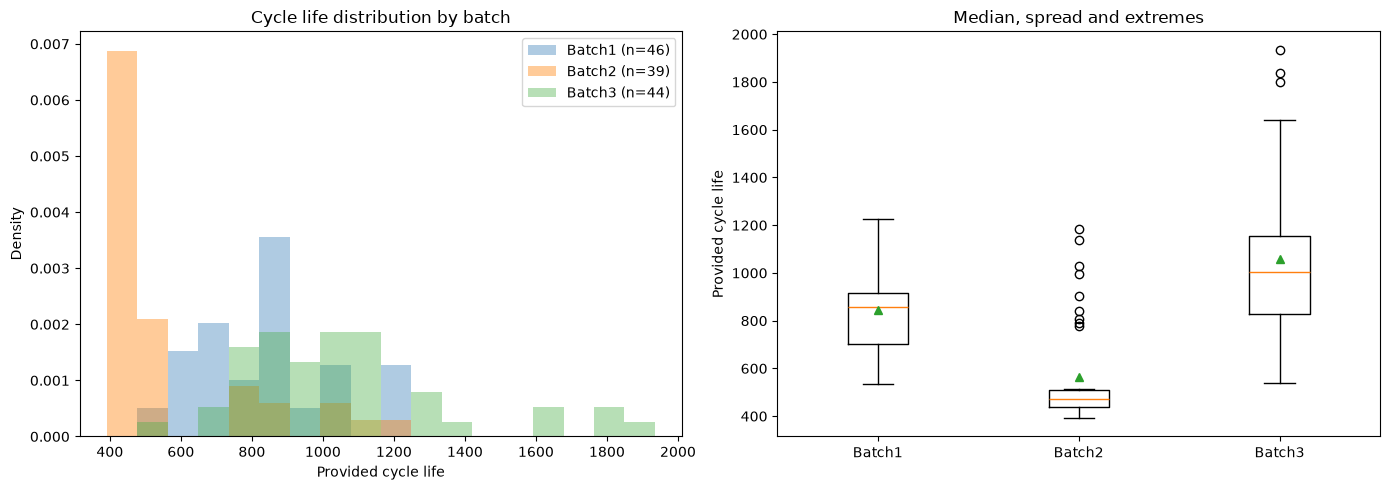

### 6. Finding
- Batch1: n=46, 평균 844.7, 중앙값 858.5, IQR 211.0, 범위 534–1227.
- Batch2: n=39, 평균 565.7, 중앙값 472.0, IQR 69.0, 범위 392–1186.
- Batch3: n=44, 평균 1059.7, 중앙값 1005.5, IQR 327.2, 범위 541–1935.

제공 레이블의 중앙값은 Batch3에서 가장 높고 Batch2에서 가장 낮다.

### 7. Interpretation
배치별 레이블 분포가 다르다. 충전 정책·측정 조건·결측 및 실험 종료 차이가 섞여 있으므로 Batch 자체가 수명 차이를 유발했다고 해석하지 않는다. 결측 수명은 이 분포에서 빠져 있다.

### 8. Modeling Implication / Data Leakage
cycle_life는 정답 레이블이며 입력 Feature가 아니다. 향후 셀 단위 분할과 Batch별 성능 확인이 필요하다. 관측된 수명 범위만으로 전체 모집단의 범위나 미관측 셀의 최종 수명을 단정하지 않는다.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins = np.linspace(cycle_life_df['cycle_life'].min(), cycle_life_df['cycle_life'].max(), 19)
for b in batch_names:
    vals = cycle_life_df.loc[cycle_life_df['batch'] == b, 'cycle_life']
    axes[0].hist(vals, bins=bins, density=True, alpha=.40, label=f'{b} (n={len(vals)})', color=batch_colors[b])
axes[0].set(xlabel='Provided cycle life', ylabel='Density', title='Cycle life distribution by batch')
axes[0].legend()
axes[1].boxplot([cycle_life_df.loc[cycle_life_df['batch'] == b, 'cycle_life'] for b in batch_names],
    tick_labels=batch_names, showmeans=True)
axes[1].set(ylabel='Provided cycle life', title='Median, spread and extremes')
plt.tight_layout(); save_figure('eda1_cycle_life')
rows = [f"- {b}: n={int(life_stats.loc[b, 'count'])}, 평균 {life_stats.loc[b, 'mean']:.1f}, "
        f"중앙값 {life_stats.loc[b, '50%']:.1f}, IQR {life_stats.loc[b, 'IQR']:.1f}, "
        f"범위 {life_stats.loc[b, 'min']:.0f}–{life_stats.loc[b, 'max']:.0f}." for b in batch_names]
hi, lo = life_stats['50%'].idxmax(), life_stats['50%'].idxmin()
show_finding('\n'.join(rows) + f'\n\n제공 레이블의 중앙값은 {hi}에서 가장 높고 {lo}에서 가장 낮다.',
    '배치별 레이블 분포가 다르다. 충전 정책·측정 조건·결측 및 실험 종료 차이가 섞여 있으므로 '
    'Batch 자체가 수명 차이를 유발했다고 해석하지 않는다. 결측 수명은 이 분포에서 빠져 있다.',
    'cycle_life는 정답 레이블이며 입력 Feature가 아니다. 향후 셀 단위 분할과 Batch별 성능 확인이 필요하다. '
    '관측된 수명 범위만으로 전체 모집단의 범위나 미관측 셀의 최종 수명을 단정하지 않는다.')

## EDA 2 — 열화 곡선

### 1. Question
방전 용량은 사이클에 따라 어떻게 변하며, Batch별 초기 용량과 Cycle10→100 변화는 다른가?

### 2. 사용 변수
`df`: `summary.cycle`, `QD`, `batch`, `cell_id`, `cycle_life`.
`cycle_life` 색상과 전체 수명 구간은 EDA용 미래 정보다.

### 3. 계산 방법
원본 번호를 유지하고 QD≤0은 비측정값 후보로 제외한다. 각 셀의 Cycle10·100 QD와
차이·변화율을 계산한다. 그래프는 0<QD≤1.5 Ah만 보여 주고 제외한 점 개수를 표에 남긴다.
이 시각화 상한은 정상 여부를 확정하는 기준이 아니며 Feature·수명 레이블을 삭제하지 않는다.
0.88 Ah 선은 1.1 Ah의 80% 참고선이다. 제공 cycle_life를 이 선으로 재계산하지 않는다.

### 4. 핵심 통계
초기 구간 통계는 전체 열화곡선의 종료 시점을 사용하지 않는다.

In [6]:
df_clean = df[df['QD'].between(0, 1.5, inclusive='right')].copy()
qd_points = df[df['cycle'].isin([10, 100])].pivot(index='cell_id', columns='cycle', values='QD')
degradation = cell_table.merge(qd_points.rename(columns={10:'QD10',100:'QD100'}), on='cell_id')
degradation['delta_QD_100_10'] = degradation['QD100'] - degradation['QD10']
degradation['pct_change_100_10'] = 100 * degradation['delta_QD_100_10'] / degradation['QD10']
endpoint_records = []
for cid, part in df[df['QD'] > 0].groupby('cell_id'):
    part = part.sort_values('cycle')
    endpoint_records.append({'cell_id':cid,'first_valid_QD':part['QD'].iloc[0],
        'last_valid_QD':part['QD'].iloc[-1], 'last_observed_cycle':int(part['cycle'].iloc[-1])})
degradation = degradation.merge(pd.DataFrame(endpoint_records),on='cell_id',validate='one_to_one')
degradation['endpoint_change_pct'] = 100 * (degradation['last_valid_QD']/degradation['first_valid_QD']-1)
deg_stats = degradation.groupby('batch').agg(n=('cell_id','size'),
    median_QD10=('QD10','median'), median_QD100=('QD100','median'),
    median_delta_QD=('delta_QD_100_10','median'),
    median_pct_change=('pct_change_100_10','median'),
    increasing_cells=('delta_QD_100_10',lambda x: int((x>0).sum())),
    median_first_QD=('first_valid_QD','median'),median_last_QD=('last_valid_QD','median'),
    median_endpoint_change_pct=('endpoint_change_pct','median'),
    decreasing_endpoints=('endpoint_change_pct',lambda x:int((x<0).sum())))
deg_stats['hidden_plot_points'] = df.groupby('batch').size() - df_clean.groupby('batch').size()
display(deg_stats.round(6))
degradation.to_csv(OUTPUT_DIR / 'eda2_cell_degradation.csv', index=False)

,n,median_QD10,median_QD100,median_delta_QD,median_pct_change,increasing_cells,median_first_QD,median_last_QD,median_endpoint_change_pct,decreasing_endpoints,hidden_plot_points
batch,,,,,,,,,,,
Batch1,46,1.082121,1.081524,-0.000903,-0.083282,13,1.078689,0.880979,-18.139156,46,48
Batch2,47,1.096198,1.097549,0.000254,0.023314,25,1.092050,0.826613,-24.347937,45,11
Batch3,46,1.068504,1.066700,-0.001247,-0.116172,5,1.064634,0.880433,-17.252603,46,0


### 5. 그래프
Batch별 전체 곡선이며 수명 결측은 회색이다. 수명 색상 척도는 세 Batch에 공통으로 적용한다.

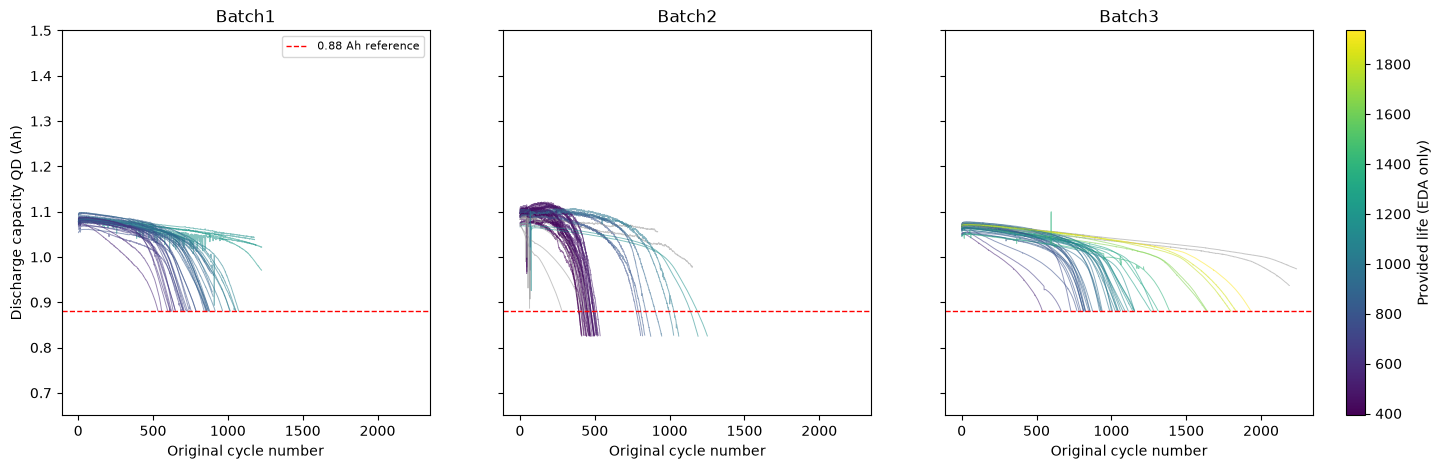

### 6. Finding
- Batch1: Cycle10→100 방전 용량 변화 중앙값 -0.00090 Ah (-0.083%), 증가한 기록 13/46, 관측 시작→마지막 용량 변화 중앙값 -18.14%, 그래프에서 숨긴 점 48개.
- Batch2: Cycle10→100 방전 용량 변화 중앙값 +0.00025 Ah (+0.023%), 증가한 기록 25/47, 관측 시작→마지막 용량 변화 중앙값 -24.35%, 그래프에서 숨긴 점 11개.
- Batch3: Cycle10→100 방전 용량 변화 중앙값 -0.00125 Ah (-0.116%), 증가한 기록 5/46, 관측 시작→마지막 용량 변화 중앙값 -17.25%, 그래프에서 숨긴 점 0개.

### 7. Interpretation
Cycle10→100의 용량 변화 중앙값은 Batch1·3에서 작은 음수, Batch2에서 작은 양수다. 초기 용량이 증가한 기록도 있으므로 초기 구간을 일률적인 감소 구간으로 설명할 수 없다. 관측 마지막 시점은 셀마다 다르고 진짜 EOL과 일치하지 않을 수 있다. 장기 변화 통계는 서로 다른 종료 시점의 EDA 요약이며, 동일 시점의 성능 비교가 아니다. 그래프에서 제외한 값은 cycle_summary.csv에 보존한다.

### 8. Modeling Implication / Data Leakage
QD10, QD100, 그 차이는 100사이클 시점 입력 후보다. 전체 곡선 기울기·EOL 도달 시점·전체 최대 용량·최종 용량·전체 기록 길이는 미래 정보이므로 초기 모델 입력에 넣지 않는다. 수명에 따른 곡선 색상은 설명용이며 입력으로 변환하지 않는다.

In [7]:
life_norm = Normalize(cycle_life_df['cycle_life'].min(), cycle_life_df['cycle_life'].max())
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True, sharey=True)
for ax, b in zip(axes, batch_names):
    for cid, sub in df_clean[df_clean['batch'] == b].groupby('cell_id'):
        life = sub['cycle_life'].iloc[0]
        color = cm.viridis(life_norm(life)) if np.isfinite(life) else '#999999'
        ax.plot(sub['cycle'], sub['QD'], color=color, linewidth=.7, alpha=.55)
    ax.axhline(.88, color='red', ls='--', lw=1, label='0.88 Ah reference')
    ax.set(title=b, xlabel='Original cycle number', ylim=(.65,1.5))
axes[0].set_ylabel('Discharge capacity QD (Ah)')
axes[0].legend(fontsize=8)
fig.colorbar(cm.ScalarMappable(norm=life_norm,cmap='viridis'),ax=axes.tolist(),label='Provided life (EDA only)',fraction=.025,pad=.025)
save_figure('eda2_degradation')
show_finding('\n'.join(f"- {b}: Cycle10→100 방전 용량 변화 중앙값 "
    f"{deg_stats.loc[b,'median_delta_QD']:+.5f} Ah ({deg_stats.loc[b,'median_pct_change']:+.3f}%), "
    f"증가한 기록 {int(deg_stats.loc[b,'increasing_cells'])}/{int(deg_stats.loc[b,'n'])}, "
    f"관측 시작→마지막 용량 변화 중앙값 {deg_stats.loc[b,'median_endpoint_change_pct']:+.2f}%, "
    f"그래프에서 숨긴 점 {int(deg_stats.loc[b,'hidden_plot_points'])}개." for b in batch_names),
    'Cycle10→100의 용량 변화 중앙값은 Batch1·3에서 작은 음수, Batch2에서 작은 양수다. '
    '초기 용량이 증가한 기록도 있으므로 초기 구간을 일률적인 감소 구간으로 설명할 수 없다. '
    '관측 마지막 시점은 셀마다 다르고 진짜 EOL과 일치하지 않을 수 있다. 장기 변화 통계는 '
    '서로 다른 종료 시점의 EDA 요약이며, 동일 시점의 성능 비교가 아니다. '
    '그래프에서 제외한 값은 cycle_summary.csv에 보존한다.',
    'QD10, QD100, 그 차이는 100사이클 시점 입력 후보다. 전체 곡선 기울기·EOL 도달 시점·'
    '전체 최대 용량·최종 용량·전체 기록 길이는 미래 정보이므로 초기 모델 입력에 넣지 않는다. '
    '수명에 따른 곡선 색상은 설명용이며 입력으로 변환하지 않는다.')

## EDA 3 — ΔQ(V): Cycle100 − Cycle10

### 1. Question
동일 전압에서 Cycle10과 Cycle100의 방전 곡선 차이는 어느 정도이며, 그 차이의 분산은 수명과 연관되는가?

### 2. 사용 변수
셀별 `Vdlin`, `cycles[10]['Qdlin']`, `cycles[100]['Qdlin']`, `cycle_life`, `batch`.
선택 로딩한 `cycles` 사전의 키는 실제 사이클 번호 10·100이다.

### 3. 계산 방법
ΔQ(V)=Q100(V)−Q10(V). 두 배열이 유한한 1,000점인지와 동일 전압축인지 확인한다.
분산은 `ddof=0`, Feature는 `log10(var(ΔQ))`로 정의한다. 재보간하지 않는다.
대표 셀은 각 Batch의 수명 중앙값에 가장 가까운 기록을 EDA용으로 선택한다.

### 4. 핵심 통계
곡선 유효성, ΔQ 범위·분산, 수명과의 Pearson·Spearman 및 쌍별 n을 제시한다.

In [8]:
delta_records, delta_curves = [], {}
v_reference = None
for b in batch_names:
    for i, cell in enumerate(batches[b]):
        v, q10, q100 = cell['Vdlin'], cell['cycles'][10], cell['cycles'][100]
        assert q10 is not None and q100 is not None
        assert len(v) == len(q10) == len(q100) == 1000
        assert np.isfinite(q10).all() and np.isfinite(q100).all()
        if v_reference is None: v_reference = v
        assert np.array_equal(v, v_reference)
        dq = q100 - q10
        cid = f'{b}_C{i:03d}'
        variance = float(np.var(dq, ddof=0))
        delta_curves[cid] = dq
        delta_records.append({'cell_id':cid, 'batch':b, 'cycle_life':cell['cycle_life'],
            'delta_Q_mean':dq.mean(),'delta_Q_min':dq.min(),'delta_Q_max':dq.max(),
            'delta_Q_variance':variance,'log_var_delta_Q':np.log10(variance) if variance>0 else np.nan})
delta_features = pd.DataFrame(delta_records)
delta_stats = delta_features.groupby('batch').agg(n_curves=('cell_id','size'),
    median_delta_mean=('delta_Q_mean','median'),
    median_log_var=('log_var_delta_Q','median'),
    min_log_var=('log_var_delta_Q','min'), max_log_var=('log_var_delta_Q','max'))
delta_corr = correlation_table(delta_features, ['log_var_delta_Q'])
display(delta_stats.round(6)); display(delta_corr.round(4))
delta_features.to_csv(OUTPUT_DIR / 'eda3_delta_features.csv',index=False)
delta_corr.to_csv(OUTPUT_DIR / 'eda3_delta_correlations.csv',index=False)

,n_curves,median_delta_mean,median_log_var,min_log_var,max_log_var
batch,,,,,
Batch1,46,-0.015740,-3.851160,-5.014861,-3.350338
Batch2,47,-0.024684,-3.494881,-4.770611,-2.684918
Batch3,46,-0.010241,-4.198987,-5.098856,-3.451658


,batch,feature,n,Pearson_r,Spearman_rho
0,All,log_var_delta_Q,129,-0.8506,-0.8921
1,Batch1,log_var_delta_Q,46,-0.8861,-0.8712
2,Batch2,log_var_delta_Q,39,-0.9019,-0.7090
3,Batch3,log_var_delta_Q,44,-0.7019,-0.7972


### 5. 그래프
대표 셀의 두 방전 곡선, 전체 ΔQ(V), 분산 Feature–수명 산점도를 확인한다.

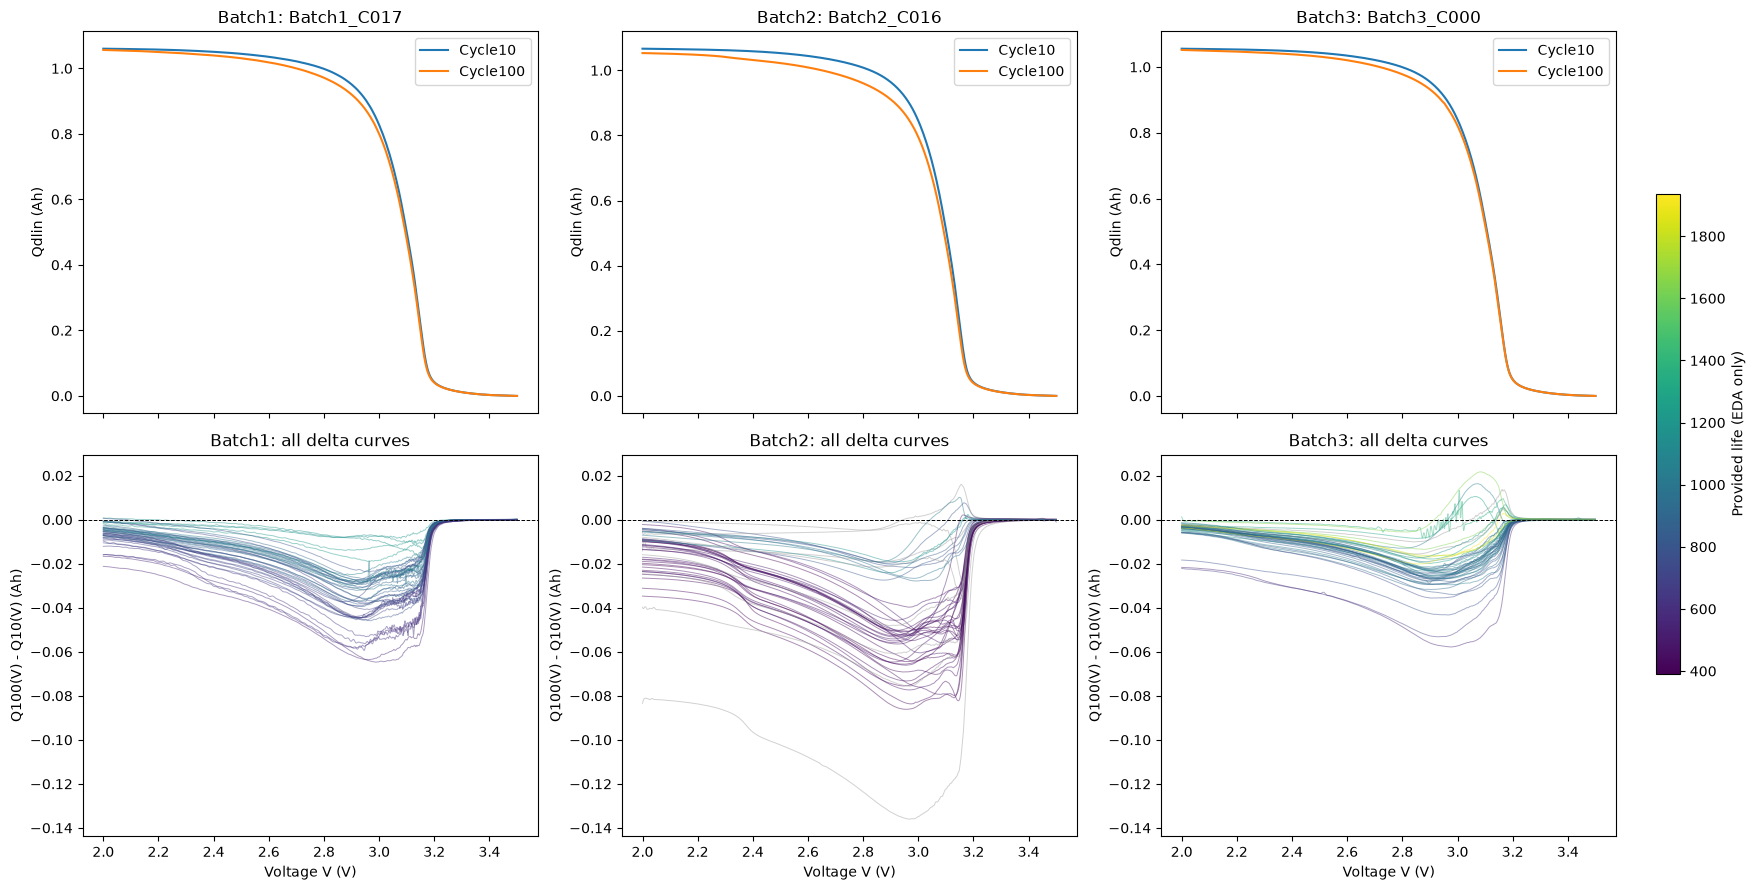

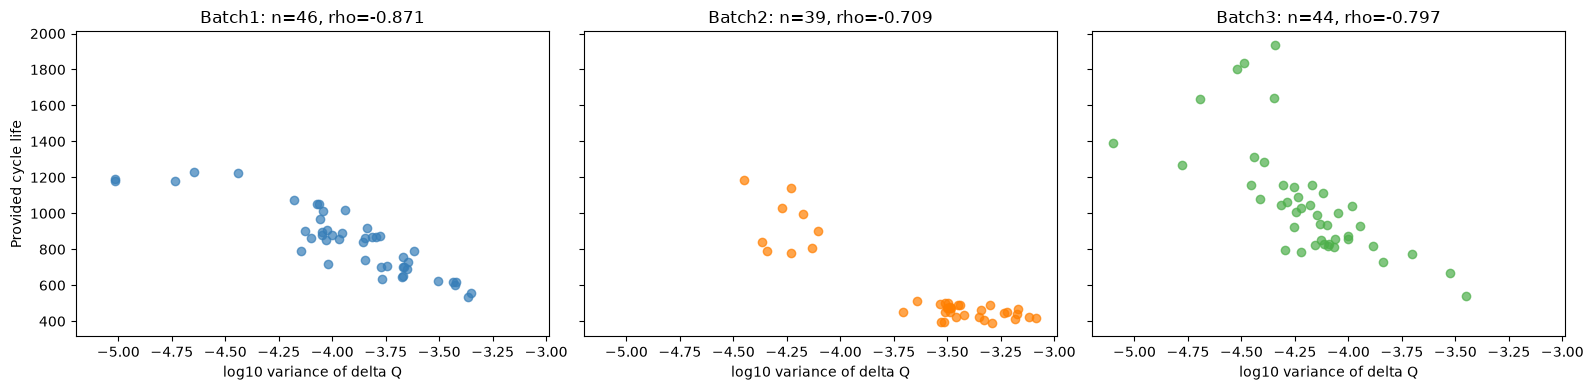

### 6. Finding
139개 모두 Cycle10·100 Qdlin이 유한한 1,000점이며 전압축이 동일했다.

- All: n=129, log10 분산–수명 Pearson r=-0.851, Spearman ρ=-0.892.
- Batch1: n=46, log10 분산–수명 Pearson r=-0.886, Spearman ρ=-0.871.
- Batch2: n=39, log10 분산–수명 Pearson r=-0.902, Spearman ρ=-0.709.
- Batch3: n=44, log10 분산–수명 Pearson r=-0.702, Spearman ρ=-0.797.

### 7. Interpretation
세 Batch 모두 로그 분산이 클수록 제공 수명이 짧은 음의 연관을 보이며, 통합 결과와 부호가 일치한다. 따라서 단순 평균 용량과 달리 배치 내부에서도 확인되는 후보 신호다. ΔQ의 분산은 전압별 변화의 불균일성을 요약한다. 이 연관은 인과효과나 미관측 셀의 예측 성능을 입증하지 않는다.

### 8. Modeling Implication / Data Leakage
ΔQ와 log 분산은 Cycle100 관측 이후 사용할 수 있는 후보 Feature다. 초기 5사이클 모델에는 미래 정보가 된다. 대표 셀을 수명으로 선택한 과정·수명 색상은 EDA 전용이다. 전체 데이터에서 확인한 상관을 보고 Feature를 선택했다면 이후 독립 검증 또는 중첩 검증이 필요하다.

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), sharex=True)
representatives = []
for col, b in enumerate(batch_names):
    meta = cycle_life_df[cycle_life_df['batch'] == b]
    row = meta.loc[(meta['cycle_life']-meta['cycle_life'].median()).abs().idxmin()]
    cell = batches[b][int(row['source_cell_index'])]
    representatives.append(row['cell_id'])
    axes[0,col].plot(cell['Vdlin'],cell['cycles'][10],label='Cycle10')
    axes[0,col].plot(cell['Vdlin'],cell['cycles'][100],label='Cycle100')
    axes[0,col].set(title=f"{b}: {row['cell_id']}",ylabel='Qdlin (Ah)')
    axes[0,col].legend()
    for _, m in cell_table[cell_table['batch']==b].iterrows():
        color = cm.viridis(life_norm(m['cycle_life'])) if np.isfinite(m['cycle_life']) else '#999999'
        axes[1,col].plot(v_reference,delta_curves[m['cell_id']],color=color,alpha=.45,lw=.7)
    axes[1,col].axhline(0,color='black',lw=.7,ls='--')
    axes[1,col].set(xlabel='Voltage V (V)',ylabel='Q100(V) - Q10(V) (Ah)',title=f'{b}: all delta curves')
delta_min=min(curve.min() for curve in delta_curves.values())
delta_max=max(curve.max() for curve in delta_curves.values())
padding=(delta_max-delta_min)*.05
for ax in axes[1,:]:ax.set_ylim(delta_min-padding,delta_max+padding)
plt.tight_layout()
fig.colorbar(cm.ScalarMappable(norm=life_norm,cmap='viridis'),ax=axes.ravel().tolist(),
    fraction=.015,pad=.025,label='Provided life (EDA only)')
save_figure('eda3_delta_curves')
fig, axes = plt.subplots(1,3,figsize=(16,4),sharex=True,sharey=True)
for ax,b in zip(axes,batch_names):
    part=delta_features[(delta_features['batch']==b)&np.isfinite(delta_features['cycle_life'])]
    ax.scatter(part['log_var_delta_Q'],part['cycle_life'],color=batch_colors[b],alpha=.7)
    r=delta_corr[delta_corr['batch']==b].iloc[0]
    ax.set(title=f"{b}: n={int(r['n'])}, rho={r['Spearman_rho']:.3f}",xlabel='log10 variance of delta Q')
axes[0].set_ylabel('Provided cycle life')
plt.tight_layout(); save_figure('eda3_delta_vs_life')
show_finding('139개 모두 Cycle10·100 Qdlin이 유한한 1,000점이며 전압축이 동일했다.\n\n'+
    '\n'.join(f"- {r.batch}: n={r.n}, log10 분산–수명 Pearson r={r.Pearson_r:+.3f}, "
    f"Spearman ρ={r.Spearman_rho:+.3f}." for r in delta_corr.itertuples()),
    '세 Batch 모두 로그 분산이 클수록 제공 수명이 짧은 음의 연관을 보이며, 통합 결과와 '
    '부호가 일치한다. 따라서 단순 평균 용량과 달리 배치 내부에서도 확인되는 후보 신호다. '
    'ΔQ의 분산은 전압별 변화의 불균일성을 요약한다. 이 연관은 인과효과나 미관측 셀의 '
    '예측 성능을 입증하지 않는다.',
    'ΔQ와 log 분산은 Cycle100 관측 이후 사용할 수 있는 후보 Feature다. 초기 5사이클 모델에는 '
    '미래 정보가 된다. 대표 셀을 수명으로 선택한 과정·수명 색상은 EDA 전용이다. '
    '전체 데이터에서 확인한 상관을 보고 Feature를 선택했다면 이후 독립 검증 또는 중첩 검증이 필요하다.')

## EDA 4 — 충전 조건(C-rate)과 Cycle Life

### 1. Question
같은 Batch 안에서 충전 정책별 수명은 어떻게 다르며, 첫 단계 C-rate와 수명은 어떤 관계인가?

### 2. 사용 변수
`charging_policy`, `cycle_life`, `batch`. 읽을 수 있는 두 단계 정책에서 `C1`,
전환 SOC 비율 `switch_pct`, `C2`를 추출한다. 원본 정책 문자열과 접미사를 유지한다.

### 3. 계산 방법
Batch·정책별 n, 평균, 표준편차, 중앙값을 집계한다. n=1이면 표준편차를 채우지 않는다.
C1·C2·전환 비율과 수명의 상관을 Batch별·통합으로 계산한다.
정책의 C-rate는 설정값이며 실제 순간 전류 전체를 대표하지 않는다.
정책 변경·SLOWCYCLE 같은 접미사를 제거해 동일 실험으로 합치지 않는다.

### 4. 핵심 통계
정책 표본 수와 상관계수의 유효 n을 함께 확인한다.

In [10]:
policy_features = cycle_life_df.copy()
parsed = policy_features['charging_policy'].str.extract(
    r'^(?P<C1>\d+(?:\.\d+)?)C\((?P<switch_pct>\d+(?:\.\d+)?)%\)-(?P<C2>\d+(?:\.\d+)?)C')
for col in ['C1','C2','switch_pct']: policy_features[col] = pd.to_numeric(parsed[col],errors='coerce')
policy_life = policy_features.groupby(['batch','charging_policy'])['cycle_life'].agg(['mean','std','count','median'])
policy_corr = correlation_table(policy_features,['C1','C2','switch_pct'])
policy_audit = policy_features.groupby('batch').agg(n_labeled=('cell_id','size'),
    n_parsed=('C1','count'), n_policies=('charging_policy','nunique'))
display(policy_audit); display(policy_life.round(2)); display(policy_corr.round(4))
policy_life.to_csv(OUTPUT_DIR/'eda4_policy_statistics.csv')
policy_corr.to_csv(OUTPUT_DIR/'eda4_policy_correlations.csv',index=False)
policy_features.to_csv(OUTPUT_DIR/'eda4_policy_features.csv',index=False)

,n_labeled,n_parsed,n_policies
batch,,,
Batch1,46,46,23
Batch2,39,39,12
Batch3,44,44,8


mean     std  count  median
batch  charging_policy                                            
Batch1 3.6C(80%)-3.6C               1182.00    7.00      3  1179.0
       4.4C(80%)-4.4C               1074.00     NaN      1  1074.0
       4.8C(80%)-4.8C                753.00  165.46      2   753.0
       4C(80%)-4C                   1226.50    0.71      2  1226.5
       5.4C(40%)-3.6C                966.50  123.74      2   966.5
       5.4C(50%)-3.6C                899.50    3.54      2   899.5
       5.4C(50%)-3C                  847.00   83.44      2   847.0
       5.4C(60%)-3.6C                859.50    3.54      2   859.5
       5.4C(60%)-3C                  799.50  113.84      2   799.5
       5.4C(70%)-3C                  739.50   68.59      2   739.5
       5.4C(80%)-5.4C                546.50   17.68      2   546.5
       6C(30%)-3.6C                  952.50   86.97      2   952.5
       6C(40%)-3.6C                  856.00   19.80      2   856.0
       6C(40%)-3C                    935.50  115.26      2   935.5
       6C(50%)-3.6C                  792.50  118.09      2   792.5
       6C(50%)-3C                    888.50   40.31      2   888.5
       6C(60%)-3C                    744.00   18.38      2   744.0
       7C(30%)-3.6C                  722.50   27.58      2   722.5
       7C(40%)-3.6C                  621.00    5.66      2   621.0
       7C(40%)-3C                    676.00   39.60      2   676.0
       8C(15%)-3.6C                 1008.50   60.10      2  1008.5
       8C(25%)-3.6C                  676.50   36.06      2   676.5
       8C(35%)-3.6C                  607.50   12.02      2   607.5
Batch2 3.6C(30%)-6C                  421.00    7.07      2   421.0
       3.6C(9%)-5C                   394.50    2.12      2   394.5
       4.65C(44%)-5C                 482.50   23.33      2   482.5
       4.65C(69%)-6C                 452.00   11.31      2   452.0
       4.8C(80%)-4.8C                483.60   30.32      5   492.0
       4.8C(80%)-4.8C-newstructure   871.67  137.19      3   809.0
       5.2C(50%)-4.25C               454.00   20.92      5   449.0
       5.2C(58%)-4C                  477.75   18.46      4   483.0
       5.2C(58%)-4C-newstructure     961.67  157.62      3   904.0
       5.6C(26%)-4.5C                448.50   29.13      6   446.0
       5.6C(26%)-4.5C-newstructure   991.33  197.56      3   997.0
       6C(60%)-3C                    400.00   11.31      2   400.0
Batch3 3.7C(31%)-5.9C-newstructure   660.00  115.66      3   667.0
       4.8C(80%)-4.8C-newstructure  1564.17  285.72      6  1640.0
       5.3C(54%)-4C-newstructure    1074.38  129.67      8  1051.0
       5.6C(19%)-4.6C-newstructure  1001.38  174.56      8  1038.0
       5.6C(36%)-4.3C-newstructure   930.88  135.02      8   890.5
       5.9C(15%)-4.6C-newstructure   867.00   12.73      2   867.0
       5.9C(60%)-3.1C-newstructure   866.50  191.63      2   866.5
       5C(67%)-4C-newstructure      1105.71  402.91      7  1009.0

,batch,feature,n,Pearson_r,Spearman_rho
0,All,C1,129,-0.0783,-0.0275
1,All,C2,129,-0.1248,-0.1458
2,All,switch_pct,129,0.2216,0.1605
3,Batch1,C1,46,-0.5797,-0.4827
4,Batch1,C2,46,-0.0959,0.0474
5,Batch1,switch_pct,46,0.2346,0.1852
6,Batch2,C1,39,0.1907,0.0551
7,Batch2,C2,39,-0.1163,-0.1188
8,Batch2,switch_pct,39,0.1161,0.2878
9,Batch3,C1,44,-0.0829,-0.2289


### 5. 그래프
C1–수명 산점도의 색은 C2 설정값이다. 정책별 수명 평균도 표본 수·산포와 함께 비교한다.

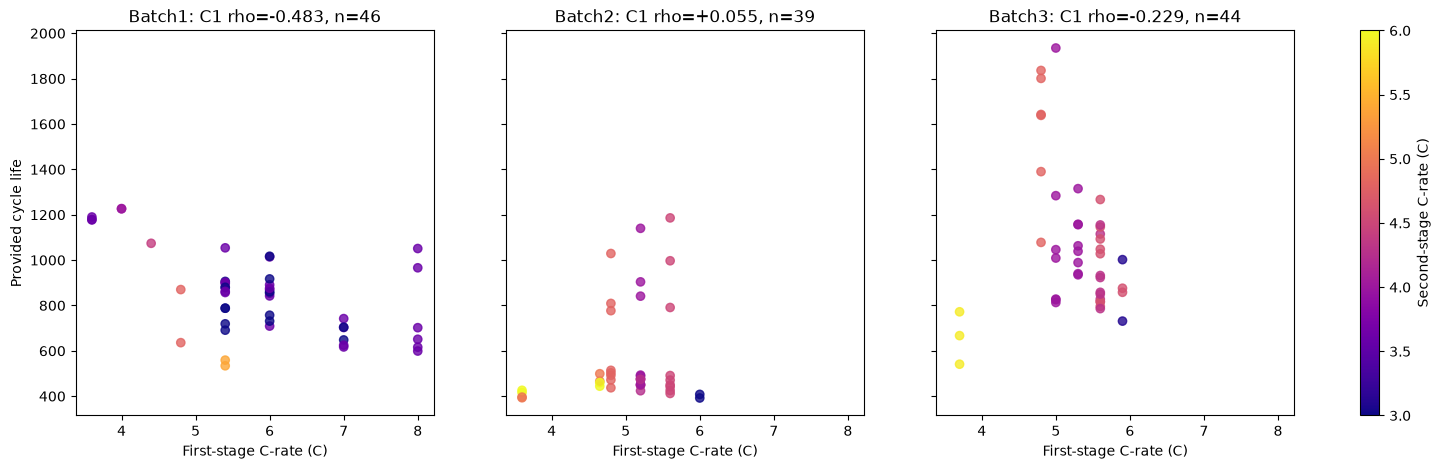

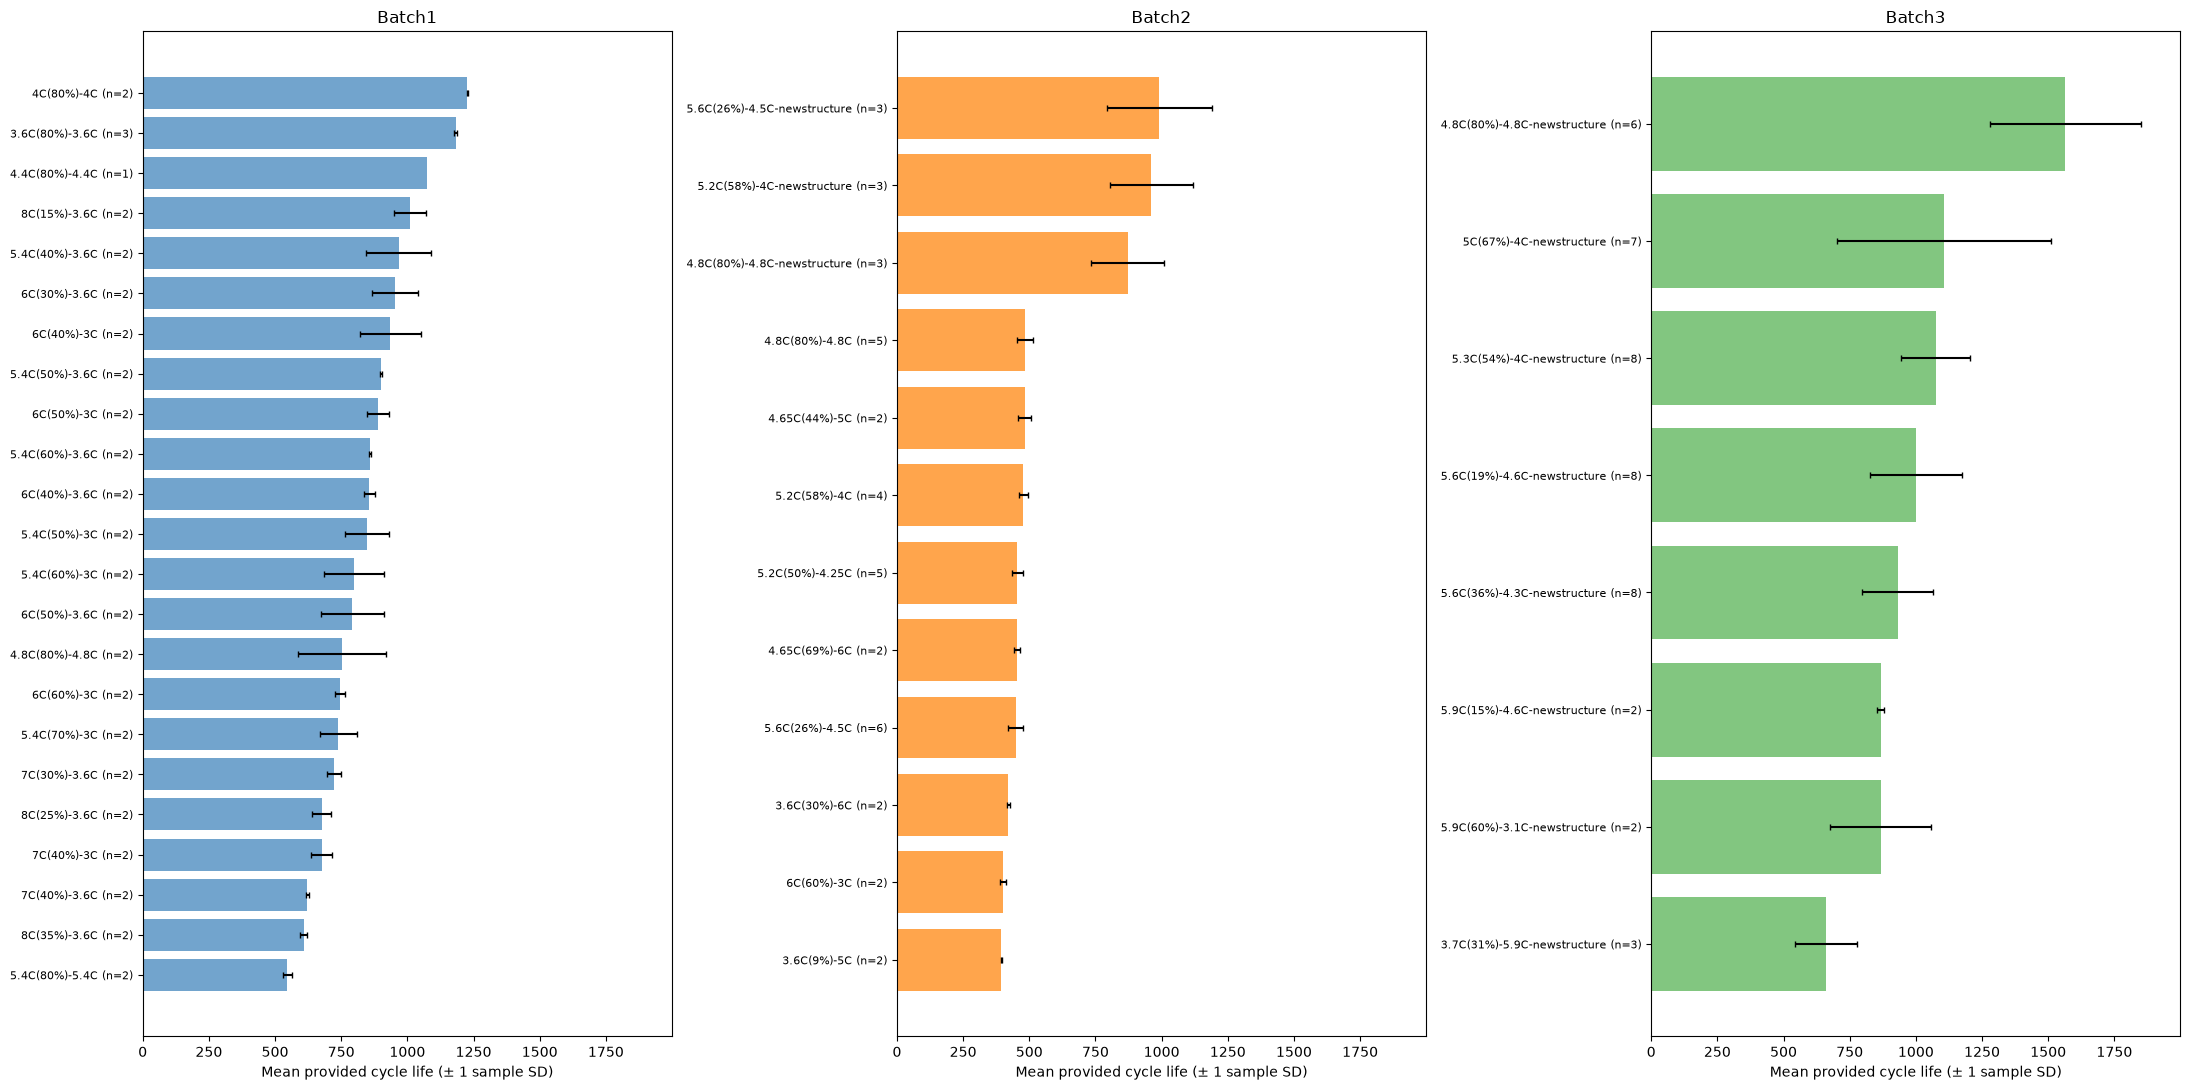

### 6. Finding
- Batch1: C1–수명 ρ=-0.483 (n=46); 정책 평균 최대 '4C(80%)-4C' 1226.5 (n=2), 최소 '5.4C(80%)-5.4C' 546.5 (n=2).
- Batch2: C1–수명 ρ=+0.055 (n=39); 정책 평균 최대 '5.6C(26%)-4.5C-newstructure' 991.3 (n=3), 최소 '3.6C(9%)-5C' 394.5 (n=2).
- Batch3: C1–수명 ρ=-0.229 (n=44); 정책 평균 최대 '4.8C(80%)-4.8C-newstructure' 1564.2 (n=6), 최소 '3.7C(31%)-5.9C-newstructure' 660.0 (n=3).

### 7. Interpretation
C1과 수명의 순위 상관은 Batch1에서 음수이나 Batch2에서 0에 가깝고 Batch3에서는 Batch1보다 음의 크기가 작다. 첫 단계 속도만으로 세 Batch의 수명을 일관되게 설명하기 어렵다. 관측된 정책별 차이는 첫 단계 속도뿐 아니라 두 번째 속도·전환 비율·Batch 조건이 함께 달라진 결과다. n이 작은 정책의 최대·최소 순위는 불안정할 수 있다. 이 결과만으로 C1의 독립적인 인과효과나 최적 정책을 확정하지 않는다.

### 8. Modeling Implication / Data Leakage
실험 시작 전에 알려진 정책 설정은 입력 후보가 될 수 있다. 수명 평균으로 만든 정책 순위나 전체 데이터 정책별 평균 수명은 target encoding에 해당하므로 그대로 입력하면 누수다. 필요하다면 학습 데이터 내부에서만 만들고 검증에 미래 레이블을 사용하지 않는다. 미관측 정책·Batch에 대한 일반화도 별도로 확인해야 한다.

In [11]:
fig,axes=plt.subplots(1,3,figsize=(17,5),sharex=True,sharey=True)
c2norm=Normalize(policy_features['C2'].min(),policy_features['C2'].max())
for ax,b in zip(axes,batch_names):
    part=policy_features[policy_features['batch']==b].dropna(subset=['C1','C2'])
    ax.scatter(part['C1'],part['cycle_life'],c=part['C2'],norm=c2norm,cmap='plasma',alpha=.8)
    row=policy_corr[(policy_corr['batch']==b)&(policy_corr['feature']=='C1')].iloc[0]
    ax.set(title=f"{b}: C1 rho={row['Spearman_rho']:+.3f}, n={int(row['n'])}",xlabel='First-stage C-rate (C)')
axes[0].set_ylabel('Provided cycle life')
fig.colorbar(cm.ScalarMappable(norm=c2norm,cmap='plasma'),ax=axes.tolist(),label='Second-stage C-rate (C)',fraction=.025)
save_figure('eda4_crate_vs_life')
fig,axes=plt.subplots(1,3,figsize=(22,11))
for ax,b in zip(axes,batch_names):
    part=policy_life.loc[b].sort_values('mean')
    y=np.arange(len(part))
    ax.barh(y,part['mean'],color=batch_colors[b],alpha=.7)
    valid=part['std'].notna()
    ax.errorbar(part.loc[valid,'mean'],y[valid],xerr=part.loc[valid,'std'],fmt='none',ecolor='black',capsize=2)
    ax.set_yticks(y,[f'{p} (n={int(n)})' for p,n in zip(part.index,part['count'])],fontsize=8)
    ax.set(title=b,xlabel='Mean provided cycle life (± 1 sample SD)')
    ax.set_xlim(0,(policy_life['mean']+policy_life['std'].fillna(0)).max()*1.08)
plt.tight_layout();save_figure('eda4_policy_life')
policy_lines=[]
for b in batch_names:
    part=policy_life.loc[b]
    best=part['mean'].idxmax();worst=part['mean'].idxmin()
    r=policy_corr[(policy_corr['batch']==b)&(policy_corr['feature']=='C1')].iloc[0]
    policy_lines.append(f"- {b}: C1–수명 ρ={r['Spearman_rho']:+.3f} (n={int(r['n'])}); "
        f"정책 평균 최대 '{best}' {part.loc[best,'mean']:.1f} (n={int(part.loc[best,'count'])}), "
        f"최소 '{worst}' {part.loc[worst,'mean']:.1f} (n={int(part.loc[worst,'count'])}).")
show_finding('\n'.join(policy_lines),
    'C1과 수명의 순위 상관은 Batch1에서 음수이나 Batch2에서 0에 가깝고 Batch3에서는 '
    'Batch1보다 음의 크기가 작다. 첫 단계 속도만으로 세 Batch의 수명을 일관되게 설명하기 어렵다. '
    '관측된 정책별 차이는 첫 단계 속도뿐 아니라 두 번째 속도·전환 비율·Batch 조건이 함께 '
    '달라진 결과다. n이 작은 정책의 최대·최소 순위는 불안정할 수 있다. '
    '이 결과만으로 C1의 독립적인 인과효과나 최적 정책을 확정하지 않는다.',
    '실험 시작 전에 알려진 정책 설정은 입력 후보가 될 수 있다. 수명 평균으로 만든 정책 순위나 '
    '전체 데이터 정책별 평균 수명은 target encoding에 해당하므로 그대로 입력하면 누수다. '
    '필요하다면 학습 데이터 내부에서만 만들고 검증에 미래 레이블을 사용하지 않는다. '
    '미관측 정책·Batch에 대한 일반화도 별도로 확인해야 한다.')

## EDA 5 — 초기 Feature와 Cycle Life의 상관관계

### 1. Question
원래 Cycle2–100의 어떤 요약 신호가 수명과 연관되며, 통합 관계가 Batch 안에서도 유지되는가?

### 2. 사용 변수
기존 Feature `mean_QD`, `std_QD`, `mean_IR`, `mean_Tavg`, `mean_Tmax`,
`mean_chargetime`을 재사용하고 `delta_QD_100_10`, `log_var_delta_Q`를 추가한다.
`cycle_life`는 비교 대상 레이블이다.

### 3. 계산 방법
Batch1의 빈 Cycle1 때문에 모든 Batch를 원래 Cycle2–100, 99개 사이클로 통일한다.
각 지표의 0·비유한값은 결측 후보로 두고 관측값만 집계한다. 측정 개수도 남긴다.
Pearson·Spearman을 전체·Batch별로 계산하며 유효 n을 제시한다.
초기 QD>1.5 Ah가 있는 셀을 제외한 민감도 비교도 수행하되 기본 집계값은 보존한다.
1.5 Ah는 분석자 기준으로, 오류 확정이나 자동 삭제 기준이 아니다.

### 4. 핵심 통계
Feature 값, 관측 개수, 쌍별 상관 표, 스파이크 후보 제외 전후 차이를 확인한다.

In [12]:
early = early_source.groupby(['batch','cell_id']).agg(
    mean_QD=('QD','mean'), std_QD=('QD','std'), mean_IR=('IR','mean'),
    mean_Tavg=('Tavg','mean'), mean_Tmax=('Tmax','mean'), mean_chargetime=('chargetime','mean'),
    n_cycles=('cycle','size'), n_QD=('QD','count'), n_IR=('IR','count'),
    n_Tavg=('Tavg','count'), n_Tmax=('Tmax','count'), n_chargetime=('chargetime','count'),
    suspect_QD_cell=('suspect_QD','any')).reset_index()
early = early.merge(cell_table[['cell_id','cycle_life']],on='cell_id',validate='one_to_one')
early = early.merge(degradation[['cell_id','delta_QD_100_10']],on='cell_id',validate='one_to_one')
early = early.merge(delta_features[['cell_id','log_var_delta_Q']],on='cell_id',validate='one_to_one')
features=['mean_QD','std_QD','mean_IR','mean_Tavg','mean_Tmax','mean_chargetime',
          'delta_QD_100_10','log_var_delta_Q']
assert (early['n_cycles']==99).all()
early_corr=correlation_table(early,features)
sensitivity=correlation_table(early[~early['suspect_QD_cell']],features)
sensitivity=early_corr.merge(sensitivity,on=['batch','feature'],suffixes=('_all','_without_suspect'))
display(early.groupby('batch')[['n_cycles','n_QD','n_IR','suspect_QD_cell']].agg(['min','max','sum']))
display(early_corr.round(4))
display(sensitivity[['batch','feature','n_all','n_without_suspect','Spearman_rho_all','Spearman_rho_without_suspect']].round(4))
early.to_csv(OUTPUT_DIR/'eda5_early_features.csv',index=False)
early_corr.to_csv(OUTPUT_DIR/'eda5_correlations.csv',index=False)
sensitivity.to_csv(OUTPUT_DIR/'eda5_sensitivity.csv',index=False)

n_cycles           n_QD           n_IR           suspect_QD_cell  \
            min max   sum  min max   sum  min max   sum             min   
batch                                                                     
Batch1       99  99  4554   99  99  4554   98  99  4543           False   
Batch2       99  99  4653   99  99  4653    0  99  3960           False   
Batch3       99  99  4554   99  99  4554   99  99  4554           False   

                   
          max sum  
batch              
Batch1   True   2  
Batch2   True   8  
Batch3  False   0

,batch,feature,n,Pearson_r,Spearman_rho
0,All,mean_QD,129,-0.5003,-0.5123
1,All,std_QD,129,-0.0712,-0.5364
2,All,mean_IR,123,-0.3356,-0.3581
3,All,mean_Tavg,129,0.2387,0.1897
4,All,mean_Tmax,129,-0.0168,-0.0115
5,All,mean_chargetime,129,-0.1941,-0.1327
6,All,delta_QD_100_10,129,-0.0231,-0.0867
7,All,log_var_delta_Q,129,-0.8506,-0.8921
8,Batch1,mean_QD,46,0.1934,0.1850
9,Batch1,std_QD,46,-0.0585,0.0528


,batch,feature,n_all,n_without_suspect,Spearman_rho_all,Spearman_rho_without_suspect
0,All,mean_QD,129,127,-0.5123,-0.5130
1,All,std_QD,129,127,-0.5364,-0.5640
2,All,mean_IR,123,121,-0.3581,-0.3654
3,All,mean_Tavg,129,127,0.1897,0.2066
4,All,mean_Tmax,129,127,-0.0115,-0.0048
5,All,mean_chargetime,129,127,-0.1327,-0.1600
6,All,delta_QD_100_10,129,127,-0.0867,-0.1085
7,All,log_var_delta_Q,129,127,-0.8921,-0.8879
8,Batch1,mean_QD,46,44,0.1850,0.2450
9,Batch1,std_QD,46,44,0.0528,0.0409


### 5. 그래프
Batch별 Feature 상관 히트맵과 통합·Batch별 수명 상관을 비교한다.

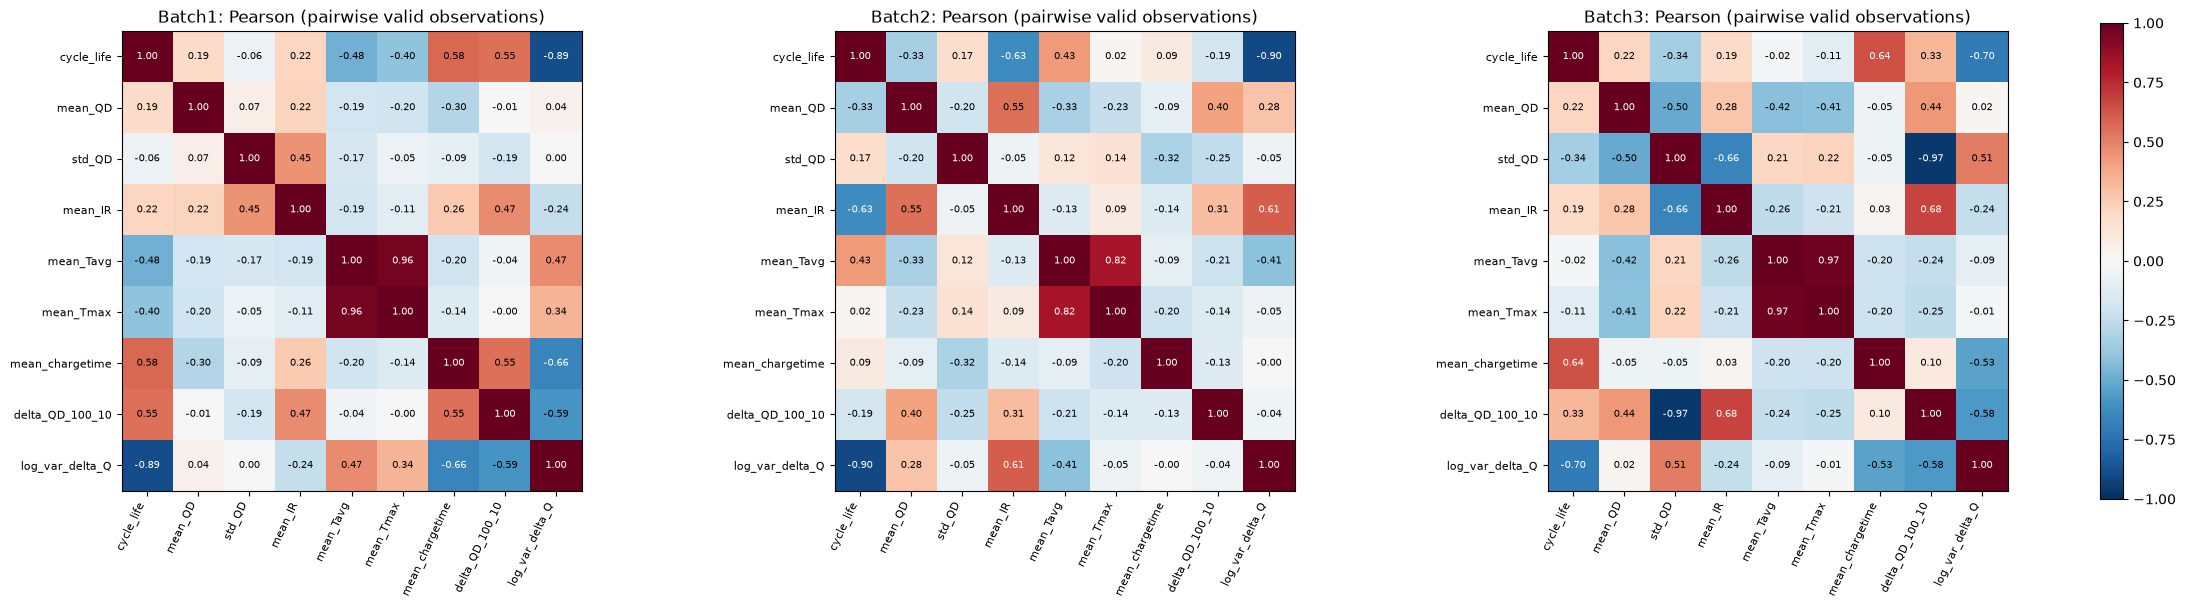

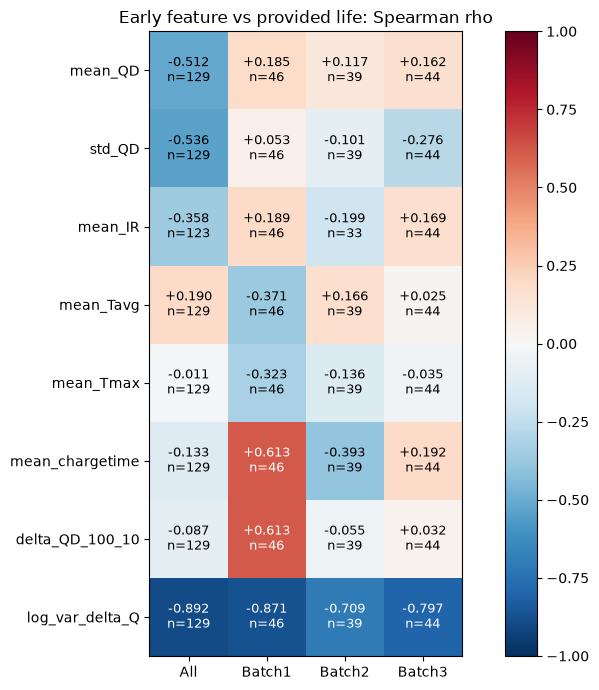

### 6. Finding
상관 절댓값 상위 3개 항목(실제 실행값):

- All: log_var_delta_Q ρ=-0.892 (n=129); std_QD ρ=-0.536 (n=129); mean_QD ρ=-0.512 (n=129)
- Batch1: log_var_delta_Q ρ=-0.871 (n=46); mean_chargetime ρ=+0.613 (n=46); delta_QD_100_10 ρ=+0.613 (n=46)
- Batch2: log_var_delta_Q ρ=-0.709 (n=39); mean_chargetime ρ=-0.393 (n=39); mean_IR ρ=-0.199 (n=33)
- Batch3: log_var_delta_Q ρ=-0.797 (n=44); std_QD ρ=-0.276 (n=44); mean_chargetime ρ=+0.192 (n=44)

통합과 Batch 내부 계수의 부호가 다른 항목: mean_QD: All vs Batch1, mean_QD: All vs Batch2, mean_QD: All vs Batch3, std_QD: All vs Batch1, mean_IR: All vs Batch1, mean_IR: All vs Batch3, mean_Tavg: All vs Batch1, mean_chargetime: All vs Batch1, mean_chargetime: All vs Batch3, delta_QD_100_10: All vs Batch1, delta_QD_100_10: All vs Batch3.

### 7. Interpretation
mean_QD는 세 Batch 내부에서 양의 순위 상관이지만 통합하면 음의 상관이다. 이는 통합 관계가 배치 구성에 영향을 받는 구체적 사례다. mean_chargetime도 Batch1·3에서 양수, Batch2와 통합 결과에서는 음수다. log_var_delta_Q만 이번 8개 항목 중 모든 Batch에서 상관 절댓값 1위이고 부호도 일치한다. 용량 스파이크 후보를 제외하면 통합 std_QD의 Pearson r은 -0.071에서 -0.330으로 바뀐다. 상위 항목은 이 데이터 안에서의 연관성 순위이며, 예측 성능 순위가 아니다. 부호나 크기가 Batch마다 다른 Feature는 배치 구성·정책과의 교란 가능성을 확인해야 한다. IR은 유효 측정이 없는 셀이 있으므로 Feature별 n을 함께 비교한다. 용량 스파이크 후보 제외 전후의 민감도도 확인한다. Feature끼리 상관이 높으면 정보가 중복될 수 있다.

### 8. Modeling Implication / Data Leakage
계산한 8개 항목은 100사이클 시점 입력 후보이며, 집계에 수명이나 Batch 후기 데이터를 사용하지 않는다. 모두 초기 5사이클에 사용 가능하다는 뜻은 아니다. 결측 대체·이상치 기준 학습·스케일링·Feature 선택은 향후 학습 분할 내부에서 수행한다. 같은 물리 셀의 중복·연속 기록 여부는 분할 전에 확인해야 한다. 모델 학습은 아직 하지 않는다.

In [13]:
fig,axes=plt.subplots(1,3,figsize=(23,7))
for ax,b in zip(axes,batch_names):
    corr_matrix=early.loc[(early['batch']==b)&np.isfinite(early['cycle_life']),['cycle_life']+features].corr()
    im=ax.imshow(corr_matrix,cmap='RdBu_r',vmin=-1,vmax=1)
    labels=corr_matrix.columns
    ax.set_xticks(range(len(labels)),labels,rotation=65,ha='right',fontsize=8)
    ax.set_yticks(range(len(labels)),labels,fontsize=8)
    ax.set_title(f'{b}: Pearson (pairwise valid observations)')
    for i in range(len(labels)):
        for j in range(len(labels)):
            val=corr_matrix.iloc[i,j]
            ax.text(j,i,f'{val:.2f}' if np.isfinite(val) else 'NA',ha='center',va='center',
                fontsize=7,color='white' if abs(val)>.6 else 'black')
colorbar=fig.colorbar(im,ax=axes.tolist(),fraction=.015,pad=.02)
fig.subplots_adjust(left=.07,right=.89,bottom=.25,top=.93,wspace=.55)
colorbar.ax.set_position([.93,.25,.012,.68])
save_figure('eda5_feature_heatmaps')
rho_matrix=early_corr.pivot(index='feature',columns='batch',values='Spearman_rho').reindex(features)[['All']+batch_names]
n_matrix=early_corr.pivot(index='feature',columns='batch',values='n').reindex(features)[['All']+batch_names]
fig,ax=plt.subplots(figsize=(9,7))
im=ax.imshow(rho_matrix,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(4),rho_matrix.columns);ax.set_yticks(range(len(features)),features)
for i in range(len(features)):
    for j in range(4):
        value=rho_matrix.iloc[i,j]
        ax.text(j,i,f'{value:+.3f}\nn={int(n_matrix.iloc[i,j])}',ha='center',va='center',fontsize=9,
            color='white' if abs(value)>.6 else 'black')
ax.set_title('Early feature vs provided life: Spearman rho')
fig.colorbar(im,ax=ax);plt.tight_layout();save_figure('eda5_life_correlations')
lines=[]
for b in ['All']+batch_names:
    part=early_corr[early_corr['batch']==b].dropna(subset=['Spearman_rho'])
    ranked=part.loc[part['Spearman_rho'].abs().sort_values(ascending=False).index].head(3)
    lines.append(f"- {b}: "+'; '.join(f"{r.feature} ρ={r.Spearman_rho:+.3f} (n={r.n})" for r in ranked.itertuples()))
changed=[]
for feature in features:
    a=early_corr[(early_corr['batch']=='All')&(early_corr['feature']==feature)]['Spearman_rho'].iloc[0]
    for b in batch_names:
        v=early_corr[(early_corr['batch']==b)&(early_corr['feature']==feature)]['Spearman_rho'].iloc[0]
        if np.isfinite(a) and np.isfinite(v) and a*v<0:changed.append(f'{feature}: All vs {b}')
show_finding('상관 절댓값 상위 3개 항목(실제 실행값):\n\n'+'\n'.join(lines)+
    '\n\n통합과 Batch 내부 계수의 부호가 다른 항목: '+(', '.join(changed) if changed else '없음')+'.',
    'mean_QD는 세 Batch 내부에서 양의 순위 상관이지만 통합하면 음의 상관이다. 이는 통합 '
    '관계가 배치 구성에 영향을 받는 구체적 사례다. mean_chargetime도 Batch1·3에서 양수, '
    'Batch2와 통합 결과에서는 음수다. log_var_delta_Q만 이번 8개 항목 중 모든 Batch에서 '
    '상관 절댓값 1위이고 부호도 일치한다. '
    f"용량 스파이크 후보를 제외하면 통합 std_QD의 Pearson r은 "
    f"{sensitivity.loc[(sensitivity['batch']=='All')&(sensitivity['feature']=='std_QD'),'Pearson_r_all'].iloc[0]:+.3f}에서 "
    f"{sensitivity.loc[(sensitivity['batch']=='All')&(sensitivity['feature']=='std_QD'),'Pearson_r_without_suspect'].iloc[0]:+.3f}으로 바뀐다. "
    '상위 항목은 이 데이터 안에서의 연관성 순위이며, 예측 성능 순위가 아니다. 부호나 크기가 '
    'Batch마다 다른 Feature는 배치 구성·정책과의 교란 가능성을 확인해야 한다. IR은 유효 측정이 '
    '없는 셀이 있으므로 Feature별 n을 함께 비교한다. 용량 스파이크 후보 제외 전후의 민감도도 '
    '확인한다. Feature끼리 상관이 높으면 정보가 중복될 수 있다.',
    '계산한 8개 항목은 100사이클 시점 입력 후보이며, 집계에 수명이나 Batch 후기 데이터를 '
    '사용하지 않는다. 모두 초기 5사이클에 사용 가능하다는 뜻은 아니다. 결측 대체·이상치 기준 학습·'
    '스케일링·Feature 선택은 향후 학습 분할 내부에서 수행한다. 같은 물리 셀의 중복·연속 기록 '
    '여부는 분할 전에 확인해야 한다. 모델 학습은 아직 하지 않는다.')

## DAY1 성과물과 다음 판단

5개 EDA에 Question→변수→계산→통계→그래프→Finding→Interpretation→Modeling Implication을 남겼다.
수치는 실제 실행 출력을 기준으로 읽는다. 초기 Feature 정의와 제외 사유는 CSV에서도 확인할 수 있다.
저장된 CSV는 분석용 파생 표이며, 원본 데이터를 대체하지 않는다.

| 데이터·집계 | EDA 용도 | 100사이클 예측 입력 |
|---|---|---|
| Cycle2–100 summary Feature | 초기 신호의 연관성 | 후보 |
| Q100(V)−Q10(V)와 그 분산 | 초기 곡선 차이 | 후보 |
| 시작 전에 알려진 정책 설정 | 정책 비교 | 사용 가능 여부·운용 조건 확인 |
| cycle_life | 레이블·색상·분포 | 입력 불가 |
| 전체 열화 곡선·최종 사이클·기록 길이 | 장기 변화·결측 확인 | 입력 불가 |
| 전체 정책 평균 수명·수명 순위 | 설명용 비교 | 그대로 입력 불가 |
| 전체 데이터에서 선택한 Feature 순위 | 탐색 | 독립 검증 필요 |

이번 실행에서 모델은 학습하지 않으며 예측 성능·최적 정책·인과효과를 주장하지 않는다.
모델링 전에 물리 셀의 중복·연속 기록, 레이블 정의, 셀·Batch 단위 분할 방침을 확인해야 한다.

In [14]:
source_after = {name: ((DATA_DIR/name).stat().st_size,(DATA_DIR/name).stat().st_mtime_ns)
                for name in batch_files.values()}
assert source_before == source_after, 'Source MAT files changed during execution'
if scratch_sha is not None:
    assert scratch_sha == hashlib.sha256(scratch_path.read_bytes()).hexdigest()
assert early['cell_id'].is_unique and len(early)==139
assert len(delta_features)==139 and len(excluded_cells)==10
assert np.isfinite(delta_features['log_var_delta_Q']).all()
pd.DataFrame({'check':['raw cells','labeled cells','delta curves','early features','missing life'],
    'count':[len(cell_table),len(cycle_life_df),len(delta_features),len(early),len(excluded_cells)]}).to_csv(
    OUTPUT_DIR/'verification.csv',index=False)
manifest={'executed_at':datetime.now(ZoneInfo('Asia/Seoul')).isoformat(),
    'source_files':list(batch_files.values()), 'excluded_file':'2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat',
    'source_stat_unchanged':source_before==source_after,'scratch_sha256':scratch_sha,
    'versions':{'python':sys.version.split()[0],'numpy':np.__version__,'pandas':pd.__version__,'h5py':h5py.__version__},
    'raw_cells':len(cell_table),'labeled_cells':len(cycle_life_df),'model_trained':False}
(OUTPUT_DIR/'execution_manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2))
print('Verification passed. Source files unchanged. No model trained.')
print('Saved figures and derived CSVs to:',OUTPUT_DIR)

Verification passed. Source files unchanged. No model trained.
Saved figures and derived CSVs to: .
